In [1]:
import pandas as pd

In [2]:
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Customers:", customers.shape)
print("Reviews:", reviews.shape)
print("Sellers:", sellers.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Reviews: (99224, 7)
Sellers: (3095, 4)


In [3]:
print("Orders Data :")
print(orders.head(3))
print("\n Columns :" ,orders.columns.tolist())

Orders Data :
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  
2           2018-09-04 00:00:00  

 Columns : ['order_id', 'customer_id', 'or

In [4]:
print("Order Status : ")
print(orders['order_status'].value_counts())
print("\nPercentage")
print(orders['order_status'].value_counts(normalize=True).round(3) * 100)

Order Status : 
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Percentage
order_status
delivered      97.0
shipped         1.1
canceled        0.6
unavailable     0.6
invoiced        0.3
processing      0.3
created         0.0
approved        0.0
Name: proportion, dtype: float64


In [5]:
completed_orders = orders[orders['order_status'].isin([
    'delivered', 'canceled', 'unavailable'
])]

print("Orders after filtering:", completed_orders.shape)
print("\nRemaining statuses:")
print(completed_orders['order_status'].value_counts())

Orders after filtering: (97712, 8)

Remaining statuses:
order_status
delivered      96478
canceled         625
unavailable      609
Name: count, dtype: int64


In [6]:
completed_orders = completed_orders.copy()
completed_orders['is_return'] = completed_orders['order_status'].apply(
    lambda x: 1 if x in ['canceled', 'unavailable'] else 0
)

print("Targeted Distribution")
print(completed_orders['is_return'].value_counts())
print("\nImbalance Ratio")
total = len(completed_orders)
returns = completed_orders['is_return'].sum()
print(f"Return Rate : {returns/total*100 :.2f}%")
print(f" 1 Return for every {int(total/returns)} delivered orders")

Targeted Distribution
is_return
0    96478
1     1234
Name: count, dtype: int64

Imbalance Ratio
Return Rate : 1.26%
 1 Return for every 79 delivered orders


In [7]:
#Merging orders with order items
df = completed_orders.merge(order_items, on= 'order_id', how='left')
print("After merging order_items:", df.shape)

#Merging with Products
df = df.merge(products, on = 'product_id', how= 'left')
print("After merging products:", df.shape)

#Merging with Customers
df = df.merge(customers, on = 'customer_id', how = 'left')
print("After merging customers:", df.shape)

#Merging Reviews
df = df.merge(reviews, on = 'order_id', how = 'left')
print("After merging Reviews:", df.shape)

#Merging with sellers
df = df.merge(sellers, on = 'seller_id', how = 'left')
print("After merging sellers:", df.shape)

print("\nMASTER DATAFRAME")
print("Final shape:", df.shape)
print("Columns:\n",df.columns.tolist())

After merging order_items: (111513, 15)
After merging products: (111513, 23)
After merging customers: (111513, 27)
After merging Reviews: (112163, 33)
After merging sellers: (112163, 36)

MASTER DATAFRAME
Final shape: (112163, 36)
Columns:
 ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_return', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


In [8]:
#check for missing values
print('Missing values : ')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum()/ len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %' : missing_pct
}).sort_values('Missing %', ascending = False)

print(missing_df[missing_df['Missing Count'] > 0])


Missing values : 
                               Missing Count  Missing %
review_comment_title                   98859      88.14
review_comment_message                 65153      58.09
product_description_lenght              2329       2.08
product_name_lenght                     2329       2.08
product_photos_qty                      2329       2.08
product_category_name                   2329       2.08
order_delivered_customer_date           1324       1.18
order_delivered_carrier_date            1248       1.11
review_score                             861       0.77
review_id                                861       0.77
review_answer_timestamp                  861       0.77
review_creation_date                     861       0.77
product_length_cm                        788       0.70
product_width_cm                         788       0.70
product_weight_g                         788       0.70
product_height_cm                        788       0.70
product_id                    

In [9]:
print("=== DATA TYPES ===")
print(df.dtypes)

=== DATA TYPES ===
order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
is_return                          int64
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
product_category_name             object
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
customer_unique_id                obje

In [10]:
# Drop columns we don't need
cols_to_drop = [
    'review_comment_title',
    'review_comment_message', 
    'review_id',
    'review_creation_date',
    'review_answer_timestamp',
    'customer_city',
    'seller_city',
    'order_status',
    'customer_zip_code_prefix',
    'seller_zip_code_prefix',
    'shipping_limit_date',
    'order_approved_at'
]

df = df.drop(columns=cols_to_drop)
print("Shape after dropping useless columns:", df.shape)
print("\nRemaining columns:", df.columns.tolist())

Shape after dropping useless columns: (112163, 24)

Remaining columns: ['order_id', 'customer_id', 'order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_return', 'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_state', 'review_score', 'seller_state']


In [11]:
# Save merged dataframe for tomorrow
df.to_csv('../data/processed/merged_data.csv', index=False)
print("✅ Merged data saved to data/processed/merged_data.csv")
print("Shape saved:", df.shape)

✅ Merged data saved to data/processed/merged_data.csv
Shape saved: (112163, 24)


In [12]:
#check for Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicated rows : {duplicates}")
print(f"Total rows : {len(df)}")

Duplicated rows : 396
Total rows : 112163


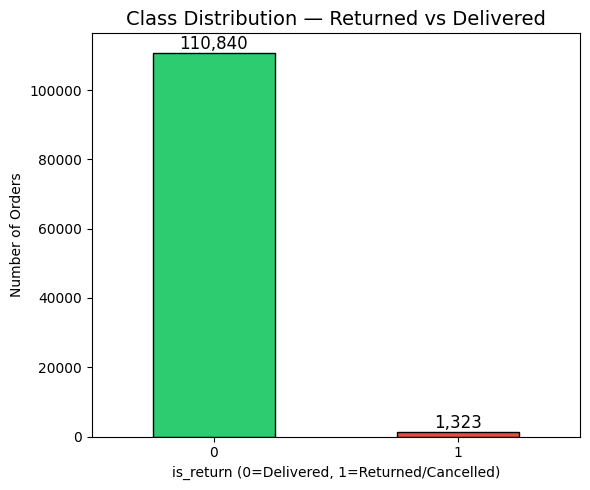

Plot saved!


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
ax = df['is_return'].value_counts().plot(kind = 'bar',
                                         color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Class Distribution — Returned vs Delivered', fontsize=14)
plt.xlabel('is_return (0=Delivered, 1=Returned/Cancelled)')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png')
plt.show()
print("Plot saved!")

In [32]:
# Remove duplicates
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")
print(f"Removed {396} duplicate rows ✅")

Shape after removing duplicates: (111767, 24)
Removed 396 duplicate rows ✅


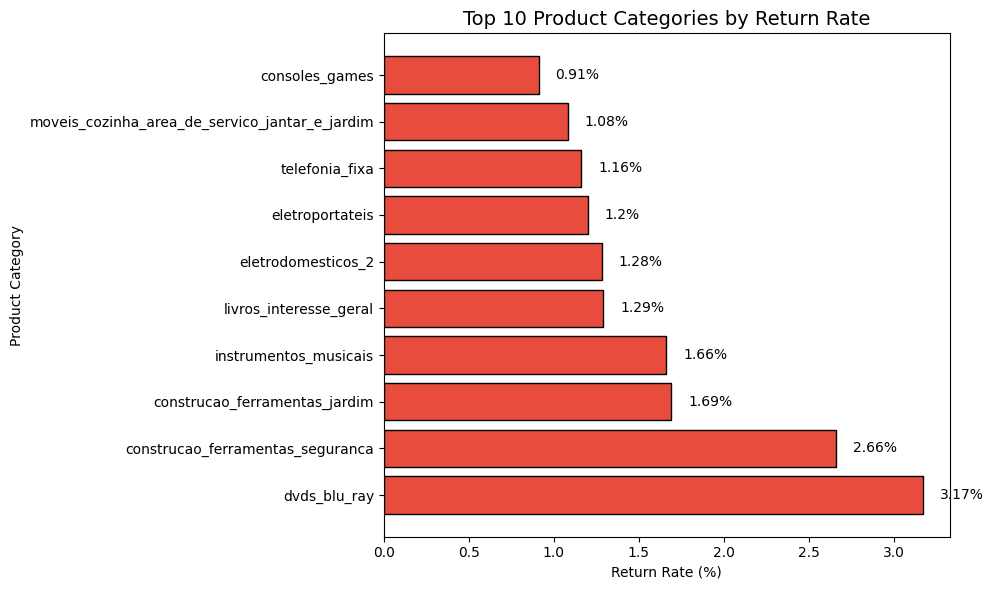

Plot saved!


In [44]:
category_stats = df.groupby('product_category_name').agg(
    total_orders=('is_return', 'count'),
    total_returns = ('is_return', 'sum')
).reset_index()

category_stats['return_rate'] = (
    category_stats['total_returns'] / category_stats['total_orders'] * 100 ).round(2)

category_stats = category_stats[category_stats['total_orders'] >= 50]

#top 10 highest return rate products
top10 = category_stats.sort_values('return_rate', ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top10['product_category_name'], 
                top10['return_rate'], 
                color='#e74c3c', edgecolor='black')
plt.title('Top 10 Product Categories by Return Rate', fontsize=14)
plt.xlabel('Return Rate (%)')
plt.ylabel('Product Category')

# Adding values on labels
for bar, val in zip(bars, top10['return_rate']):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/category_return_rate.png')
plt.show()
print("Plot saved!")

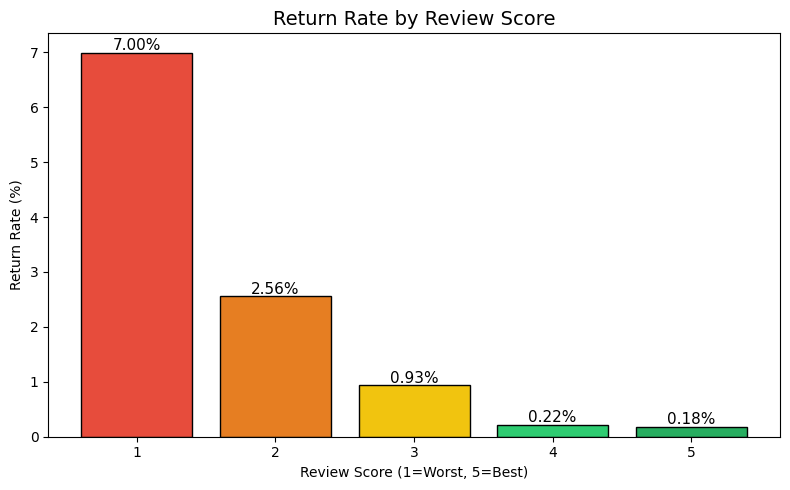

Plot saved!


In [47]:
#review score vs return rate
review_stats = df.groupby('review_score')['is_return'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(review_stats.index, review_stats.values,
               color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'],
               edgecolor='black')
plt.title('Return Rate by Review Score', fontsize=14)
plt.xlabel('Review Score (1=Worst, 5=Best)')
plt.ylabel('Return Rate (%)')

#add value labels on bars
for bar, val in zip(bars, review_stats.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/review_score_return_rate.png')
plt.show()
print("Plot saved!")

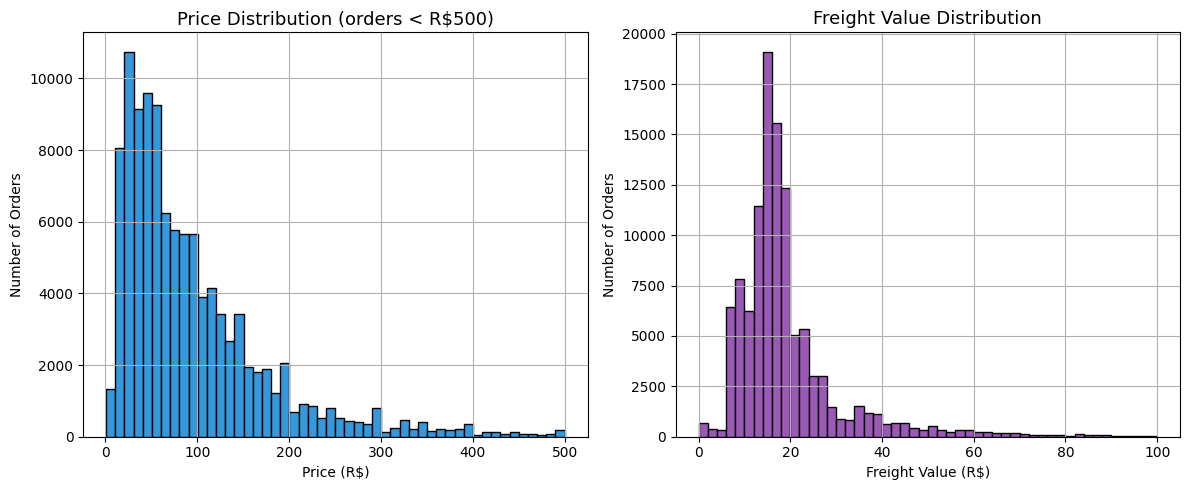

Plot saved!


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#price distribution
df[df['price'] < 500]['price'].hist(bins=50, ax=axes[0], 
    color='#3498db', edgecolor='black')
axes[0].set_title('Price Distribution (orders < R$500)', fontsize=13)
axes[0].set_xlabel('Price (R$)')
axes[0].set_ylabel('Number of Orders')

#Freight value distribution
df[df['freight_value'] < 100]['freight_value'].hist(bins=50, ax=axes[1], 
    color='#9b59b6', edgecolor='black')
axes[1].set_title('Freight Value Distribution', fontsize=13)
axes[1].set_xlabel('Freight Value (R$)')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.savefig('../data/processed/price_freight_distribution.png')
plt.show()
print("Plot saved!")

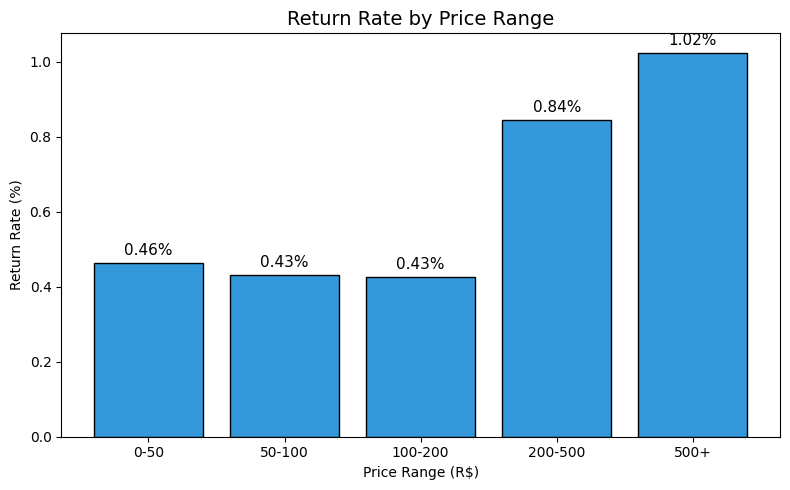

Plot saved!


In [49]:
# Does higher price = more returns?
df['price_bucket'] = pd.cut(df['price'], 
    bins=[0, 50, 100, 200, 500, 10000],
    labels=['0-50', '50-100', '100-200', '200-500', '500+'])

price_return = df.groupby('price_bucket', observed=True)['is_return'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(price_return.index, price_return.values,
               color='#3498db', edgecolor='black')
plt.title('Return Rate by Price Range', fontsize=14)
plt.xlabel('Price Range (R$)')
plt.ylabel('Return Rate (%)')

for bar, val in zip(bars, price_return.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/price_return_rate.png')
plt.show()
print("Plot saved!")

## 📊 Key EDA Observations

1. **Severe Class Imbalance** — Only 1.18% of orders are cancelled/unavailable 
   (1,323 out of 111,767). SMOTE will be critical during model training.

2. **Review Score is the Strongest Predictor** — Orders with review score 1 have 
   a 7% return rate vs only 0.18% for score 5. This 39x difference makes 
   review_score our most powerful feature.

3. **Category Matters** — dvds_blu_ray (3.17%) and construcao_ferramentas_seguranca 
   (2.66%) have the highest return rates. Product category will be an important feature.

4. **Price Distribution is Right-Skewed** — Most orders are low value (R$20-100). 
   We will need to handle outliers carefully during preprocessing.

5. **Freight Costs are Consistent** — Most freight values fall between R$15-25, 
   suggesting a standard shipping cost structure across sellers.

6. **Higher Price = Higher Return Rate** — Orders above R$500 have a 1.02% return 
   rate compared to just 0.43% for R$50-100 range. Expensive items get cancelled 
   more — likely due to buyer's remorse or financial reconsideration. 
   price_bucket will be a useful engineered feature.

7. **396 Duplicate Rows Found and Removed** — Data quality issue likely caused 
   by the merge on order_id with multiple review entries per order.

8. **High Missing Values in Review Comments** — 88% missing in comment_title 
   and 58% in comment_message — correctly dropped these columns early.